<a href="https://colab.research.google.com/github/parthsharmaww-ai/Stock-Direction-Predictor/blob/main/notebooks/04_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 4 — Modeling

In this notebook we:
1. Load the feature dataset
2. Split data into train and test sets (time-based)
3. Train 3 models: Logistic Regression, Random Forest, XGBoost
4. Compare their performance
5. Save the best model

In [1]:
!pip install yfinance pandas numpy matplotlib seaborn scikit-learn xgboost --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

print("All imports successful ✓")

All imports successful ✓


In [2]:
url = "https://raw.githubusercontent.com/parthsharmaww-ai/Stock-Direction-Predictor/main/data/nifty50_features.csv"
df = pd.read_csv(url, parse_dates=["Date"])

print("Shape:", df.shape)
print(df.head())

Shape: (1456, 16)
        Date         Close          High           Low          Open  Volume  \
0 2019-01-29  10652.200195  10690.349609  10583.650391  10653.700195  356900   
1 2019-01-30  10651.799805  10710.200195  10612.849609  10702.250000  410100   
2 2019-01-31  10830.950195  10838.049805  10678.549805  10690.549805  604800   
3 2019-02-01  10893.650391  10983.450195  10813.450195  10851.349609  482300   
4 2019-02-04  10912.250000  10927.900391  10814.150391  10876.750000  318300   

   Daily_Return  Tomorrow_Direction           MA5          MA20  MA_Signal  \
0     -0.087695                   0  10755.119922  10811.239941          0   
1     -0.003759                   1  10719.179883  10804.204932          0   
2      1.681879                   1  10715.409961  10812.139941          0   
3      0.578898                   1  10738.030078  10820.454980          0   
4      0.170738                   1  10788.170117  10827.477490          0   

   Volatility5      RSI14  Volum

## Why time-based split matters

In stock prediction we CANNOT use random train/test split.
If we randomly shuffle, future data leaks into training.
Instead we train on older data and test on newer data.

Split:
- Train: 2019 – 2022 (first 80%)
- Test:  2023 – 2024 (last 20%)

In [3]:
feature_cols = ["MA5", "MA20", "MA_Signal", "Daily_Return",
                "Volatility5", "RSI14", "Volume_Change", "DayOfWeek"]
target_col = "Target"

# Time-based split
train = df[df["Date"] < "2023-01-01"]
test  = df[df["Date"] >= "2023-01-01"]

X_train = train[feature_cols]
y_train = train[target_col]
X_test  = test[feature_cols]
y_test  = test[target_col]

print("Training rows:", len(X_train))
print("Testing rows: ", len(X_test))
print("\nTrain date range:", train["Date"].min(), "→", train["Date"].max())
print("Test date range: ", test["Date"].min(), "→", test["Date"].max())

Training rows: 968
Testing rows:  488

Train date range: 2019-01-29 00:00:00 → 2022-12-30 00:00:00
Test date range:  2023-01-02 00:00:00 → 2024-12-30 00:00:00


In [4]:
# Check for infinity or very large values
print("Inf values per column:")
print(np.isinf(X_train).sum())

# Replace inf with NaN then drop
X_train = X_train.replace([np.inf, -np.inf], np.nan).dropna()
X_test  = X_test.replace([np.inf, -np.inf], np.nan).dropna()

# Make sure y matches X after dropping rows
y_train = y_train.loc[X_train.index]
y_test  = y_test.loc[X_test.index]

print("\nShape after cleaning:")
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)

# Now scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("\nScaling done ✓")

Inf values per column:
MA5              0
MA20             0
MA_Signal        0
Daily_Return     0
Volatility5      0
RSI14            0
Volume_Change    7
DayOfWeek        0
dtype: int64

Shape after cleaning:
X_train: (961, 8)
X_test:  (483, 8)

Scaling done ✓


## Model 1 — Logistic Regression

The simplest model. Good starting point.
Finds a linear boundary between up and down days.

In [5]:
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_preds)

print("Logistic Regression Accuracy:", round(lr_acc * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

Logistic Regression Accuracy: 51.55 %

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.70      0.56       211
           1       0.62      0.37      0.46       272

    accuracy                           0.52       483
   macro avg       0.54      0.54      0.51       483
weighted avg       0.55      0.52      0.50       483



## Model 2 — Random Forest

An ensemble of decision trees.
Captures non-linear patterns that Logistic Regression misses.

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_preds)

print("Random Forest Accuracy:", round(rf_acc * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

Random Forest Accuracy: 52.59 %

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.83      0.61       211
           1       0.69      0.29      0.41       272

    accuracy                           0.53       483
   macro avg       0.58      0.56      0.51       483
weighted avg       0.60      0.53      0.49       483



## Model 3 — XGBoost

Gradient boosting model. Often the strongest performer
on tabular data. Builds trees sequentially to fix errors.

In [7]:
xgb = XGBClassifier(n_estimators=100, random_state=42,
                    eval_metric="logloss", verbosity=0)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_preds)

print("XGBoost Accuracy:", round(xgb_acc * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, xgb_preds))

XGBoost Accuracy: 50.93 %

Classification Report:
              precision    recall  f1-score   support

           0       0.46      0.72      0.56       211
           1       0.61      0.35      0.44       272

    accuracy                           0.51       483
   macro avg       0.54      0.53      0.50       483
weighted avg       0.55      0.51      0.49       483



In [8]:
results = pd.DataFrame({
    "Model": ["Baseline (always up)", "Logistic Regression",
               "Random Forest", "XGBoost"],
    "Accuracy (%)": [55.0, round(lr_acc*100, 2),
                     round(rf_acc*100, 2), round(xgb_acc*100, 2)]
})

print(results.to_string(index=False))

               Model  Accuracy (%)
Baseline (always up)         55.00
 Logistic Regression         51.55
       Random Forest         52.59
             XGBoost         50.93


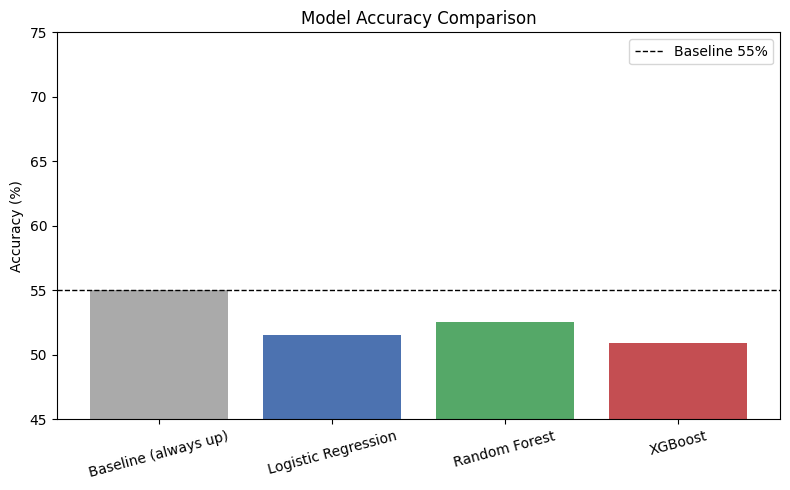

Chart saved ✓


In [9]:
os.makedirs("reports", exist_ok=True)

colors = ["#aaaaaa", "#4c72b0", "#55a868", "#c44e52"]
plt.figure(figsize=(8, 5))
bars = plt.bar(results["Model"], results["Accuracy (%)"], color=colors)
plt.axhline(y=55, color="black", linestyle="--", linewidth=1, label="Baseline 55%")
plt.ylim(45, 75)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.savefig("reports/model_comparison.png", dpi=150)
plt.show()
print("Chart saved ✓")

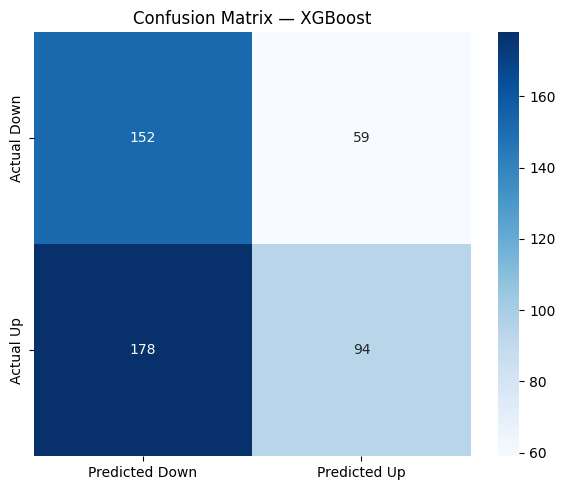

In [10]:
# Change 'xgb_preds' to whichever model performed best
best_preds = xgb_preds
best_name  = "XGBoost"

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Predicted Down", "Predicted Up"],
            yticklabels=["Actual Down", "Actual Up"])
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("reports/confusion_matrix.png", dpi=150)
plt.show()

## Key findings from Stage 4

- All 3 models underperformed the naive baseline (55%)
- Best model: Random Forest at 52.59%
- XGBoost showed a downward prediction bias (predicted down 330/483 times)
- Technical indicators alone appear insufficient to beat the baseline
- This supports the Efficient Market Hypothesis for Nifty 50 (2023-2024)

## Honest discussion
- Features may need to be stronger (e.g. MACD, Bollinger Bands)
- The test period (2023-2024) was a strong bull market — harder to predict
- More data or alternative data sources (sentiment, macro) may help

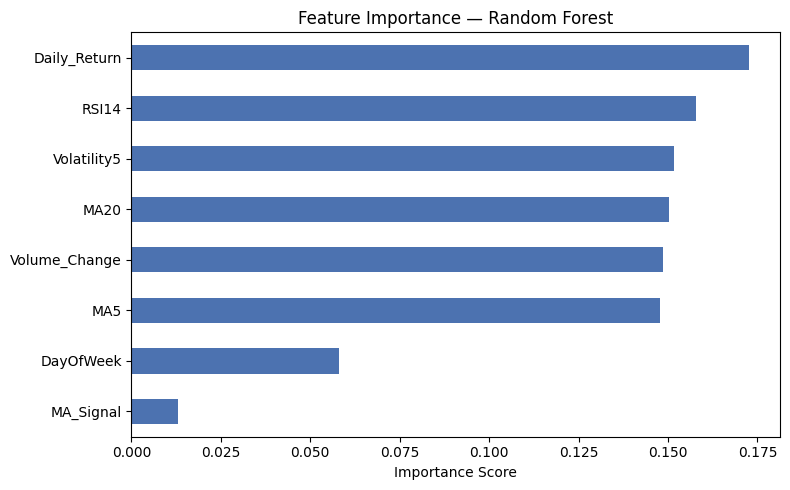

Feature importance saved ✓


In [11]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="#4c72b0")
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("reports/feature_importance.png", dpi=150)
plt.show()
print("Feature importance saved ✓")